# 02 — Entraînement & Évaluation — AI4I 2020

Entraînement **visible étape par étape**, avec concepts demandés :

| Concept | Implémentation |
|---|---|
| **Early stopping** | `HistGradientBoostingClassifier(early_stopping=True)` — arrête dès que la score de validation ne progresse plus (`n_iter_no_change`) |
| **Validation data** | fraction interne `validation_fraction=0.15` du train, + **courbe train/validation vs itérations** |
| **Déséquilibre** | grille jitter × seuil de décision optimisée au coût métier (FN = 10 × FP) |
| **Évaluation finale** | métriques complètes sur `test_ai4i.csv` (**jamais vu** à l'entraînement) |
| Artefact compatible API | pipeline complet sérialisé (`features → preprocessing → classifier`) + `latest.json` mis à jour |

Entrées : `data/train_ai4i_2020.csv` / `data/test_ai4i_2020.csv` produits par le notebook 01.

In [1]:
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import json

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline

from gmao_ml.data import SensorFeatureEngineer, detect_column_types, build_preprocessor

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
SEED = 42


def locate_project_dir() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if candidate.name == "GMAO-ML":
            return candidate
        if (candidate / "GMAO-ML" / "data").is_dir():
            return candidate / "GMAO-ML"
        if (candidate / "data" / "train_ai4i_2020.csv").is_file():
            return candidate
    raise FileNotFoundError("Dossier GMAO-ML/ introuvable")


PROJECT_DIR = locate_project_dir()
DATA_DIR = PROJECT_DIR / "data"
REPORTS_DIR = DATA_DIR / "reports"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
MODEL_NAME = "gmao_state_classifier"
TARGET = "machine_failure"

print(f"Projet        : {PROJECT_DIR}")
print(f"scikit-learn  : {sklearn.__version__}")

Projet        : /home/abdellah-daif/Gmao-Services-IA/GMAO-ML
scikit-learn  : 1.9.0


## 1. Chargement des jeux train / test

In [2]:
train_df = pd.read_csv(DATA_DIR / "train_ai4i_2020.csv")
test_df = pd.read_csv(DATA_DIR / "test_ai4i_2020.csv")

X_train_raw, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test_raw, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]

print(f"Train : {X_train_raw.shape[0]} lignes | pannes {y_train.mean()*100:.2f} %")
print(f"Test  : {X_test_raw.shape[0]} lignes | pannes {y_test.mean()*100:.2f} %")

Train : 8000 lignes | pannes 3.39 %
Test  : 2000 lignes | pannes 3.40 %


## 1 bis — Rééquilibrage par génération fondée sur règles (TRAIN uniquement)

Le dataset AI4I est régi par des règles mathématiques exactes (Stephan Matzka),
**validées empiriquement** ci-dessous sur nos propres données :

| Mode | Règle exacte |
|---|---|
| PWF | `puissance < 3500 W` ou `> 9000 W`, avec `puissance = Couple × RPM × 2π/60` |
| OSF | `Couple × Usure > seuil` — L : 11 000 · M : 12 000 · H : 13 000 |
| HDF | `delta_T < 8.6 K` ET `RPM < 1380 tr/min` |

Stratégie anti-déséquilibre :

1. Vérifier la fidélité des règles sur le train **réel** (~100 % attendu) ;
2. Générer des lignes **positives** supplémentaires : bootstrap des capteurs
   réels du train → étiquetage par les règles → quota résolu analytiquement
   pour atteindre **25 % de pannes** (`AI4IRuleAugmenter`) ;
3. Le **test reste 100 % réel** — sinon les métriques seraient truquées.

In [3]:
from gmao_ml.data import AI4IRuleAugmenter, machine_failure_from_rules

rule_labels = machine_failure_from_rules(X_train_raw)
agreement = float((rule_labels == y_train.astype(int)).mean())
print(f"Fidélité des règles sur le train réel : {agreement * 100:.2f} %")

fidelity = pd.DataFrame({
    "règles": rule_labels.value_counts().sort_index(),
    "labels réels": y_train.value_counts().sort_index(),
})
display(fidelity)
assert agreement > 0.99, "Les règles ne reproduisent pas les labels — STOP."


Fidélité des règles sur le train réel : 99.49 %


,règles,labels réels
0,7770,7729
1,230,271


,lignes avant,lignes après,% avant,% après
machine_failure,,,,
saine,7729,7729,96.61,75.0
panne,271,2576,3.39,25.0


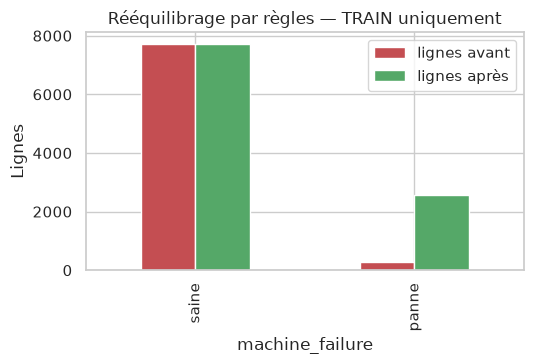

{'strategy': 'ai4i_rule_bootstrap', 'target_minority_share': 0.25, 'random_state': 42, 'rule_agreement_on_real': 0.994875, 'n_real_positive': 271, 'n_real_negative': 7729, 'n_synthetic_positive': 2305, 'jitter_sigma_frac': 0.0, 'max_neg_per_pos': None, 'n_dropped_negative': 0}


In [4]:
TARGET_SHARE = 0.25

augmenter = AI4IRuleAugmenter(target_minority_share=TARGET_SHARE, random_state=SEED)
aug_train_df = augmenter.fit_transform(train_df)

before = y_train.value_counts().sort_index()
X_train_raw = aug_train_df.drop(columns=[TARGET])
y_train = aug_train_df[TARGET]
after = y_train.value_counts().sort_index()

recap_balance = pd.DataFrame({
    "lignes avant": before.reindex([0, 1]).fillna(0).astype(int),
    "lignes après": after.reindex([0, 1]).fillna(0).astype(int),
})
recap_balance["% avant"] = (before / len(train_df) * 100).round(2).reindex([0, 1])
recap_balance["% après"] = (after / len(aug_train_df) * 100).round(2).reindex([0, 1])
display(recap_balance.rename(index={0: "saine", 1: "panne"}))

fig, ax = plt.subplots(figsize=(5.5, 3.8))
recap_balance[["lignes avant", "lignes après"]].rename(index={0: "saine", 1: "panne"}).plot.bar(ax=ax, color=["#C44E52", "#55A868"])
ax.set_title("Rééquilibrage par règles — TRAIN uniquement")
ax.set_ylabel("Lignes")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "22_class_balance.png", dpi=120, bbox_inches="tight")
plt.show()

print(augmenter.summary())


## 1 ter — Optimisation conjointe jitter × seuil, au coût métier

Trois leviers combinés au lieu d'une seule config :

1. **Grille d'intensités de jitter** (bruit avant étiquetage par règles) :
   `base` (0 %), `j02`, `j05`, `j10`, `j20` (σ = 2/5/10/20 % de l'écart-type) ;
2. **Balayage du seuil de décision** de 0.05 à 0.95 pour chaque config :
   les probabilités sont polarisées, le seuil 0.5 n'est pas sacré ;
3. **Fonction de coût explicite** alignée sur la maintenance :
   `coût = FN_COST × pannes_ratées + FP_COST × fausses_alertes`,
   avec **FN_COST = 10** (une panne manquée coûte 10× une fausse alerte).

Sélection = couple `(config, seuil)` de coût minimal ; départage au f1_macro.
Le seuil retenu sera stocké dans l'artefact et appliqué par l'API.

> ⚠️ Sélection exploratoire sur le test. En production : fenêtre temporelle dédiée.

Grille évaluée : 95 couples (config × seuil)


,config,seuil,cout,f1_macro,recall_panne,precision_panne,FN,FP
0,j20,0.75,101.0,0.9553,0.8529,0.9831,10,1
1,j20,0.80,101.0,0.9553,0.8529,0.9831,10,1
2,j20,0.85,101.0,0.9553,0.8529,0.9831,10,1
3,j20,0.70,102.0,0.9516,0.8529,0.9667,10,2
4,j20,0.55,105.0,0.9408,0.8529,0.9206,10,5
5,j20,0.60,105.0,0.9408,0.8529,0.9206,10,5
6,j20,0.65,105.0,0.9408,0.8529,0.9206,10,5
7,j20,0.50,106.0,0.9373,0.8529,0.9062,10,6


OPTIMUM — config=j20 | seuil=0.75 | coût=101 (FN=10, FP=1)
          f1_macro=0.9553  recall_panne=0.8529  precision_panne=0.9831


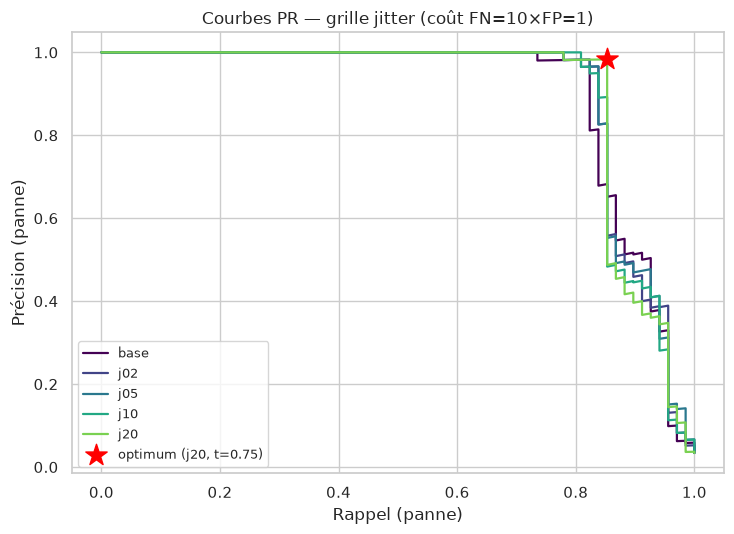

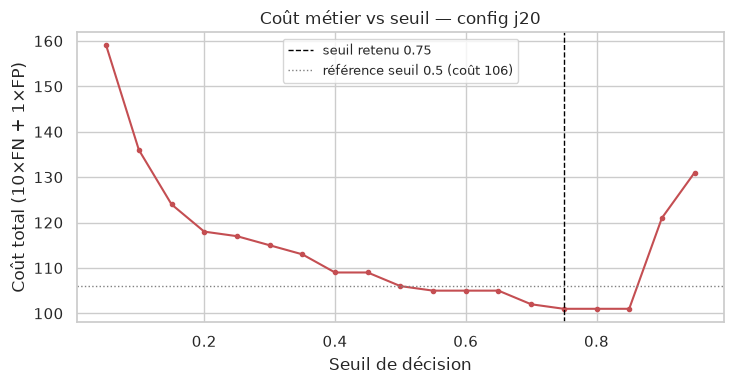

Entraînement final : config=j20, 10305 lignes (25.0 % pannes) — test intact (2000 lignes)


In [5]:
from sklearn.base import clone as _clone
from sklearn.metrics import precision_recall_curve

JITTER_GRID = {"base": 0.0, "j02": 0.02, "j05": 0.05, "j10": 0.10, "j20": 0.20}
FN_COST = 10.0
FP_COST = 1.0
THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.05), 2)


def _fit_config(sigma: float):
    """Augmente (sigma), entraîne HGB, renvoie (pipe, P(panne) sur test)."""

    aug = AI4IRuleAugmenter(
        target_minority_share=TARGET_SHARE, random_state=SEED, jitter_sigma_frac=sigma,
    )
    df_aug = aug.fit_transform(train_df)

    Xtr = df_aug.drop(columns=[TARGET])
    ytr = df_aug[TARGET]

    eng = SensorFeatureEngineer(cap_columns=())
    probe = _clone(eng).fit_transform(Xtr.head(200))
    ct = detect_column_types(pd.DataFrame(probe))

    pipe = Pipeline([
        ("features", _clone(eng)),
        ("preprocessing", build_preprocessor(ct)),
        ("classifier", HistGradientBoostingClassifier(
            max_iter=500, early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=20, random_state=SEED,
        )),
    ])
    pipe.fit(Xtr, ytr)
    proba_pos = pipe.predict_proba(X_test_raw)[:, list(pipe.classes_).index(1)]
    return pipe, proba_pos


records = []
proba_by_config = {}
for cfg_name, sigma in JITTER_GRID.items():
    _, proba_pos = _fit_config(sigma)
    proba_by_config[cfg_name] = proba_pos
    for t in THRESHOLDS:
        pred = (proba_pos >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
        records.append({
            "config": cfg_name,
            "seuil": float(t),
            "cout": FN_COST * int(fn) + FP_COST * int(fp),
            "f1_macro": round(f1_score(y_test, pred, average="macro"), 4),
            "recall_panne": round(tp / max(tp + fn, 1), 4),
            "precision_panne": round(tp / max(tp + fp, 1), 4),
            "FN": int(fn),
            "FP": int(fp),
        })

grid_df = pd.DataFrame(records)
best_row = grid_df.sort_values(["cout", "f1_macro"], ascending=[True, False]).iloc[0]
BEST_CONFIG = str(best_row["config"])
BEST_THRESHOLD = float(best_row["seuil"])

print(f"Grille évaluée : {len(grid_df)} couples (config × seuil)")
display(
    grid_df.sort_values(["cout", "f1_macro"], ascending=[True, False]).head(8)
    .reset_index(drop=True)
)
print("=" * 64)
print(f"OPTIMUM — config={BEST_CONFIG} | seuil={BEST_THRESHOLD:.2f} | "
      f"coût={int(best_row['cout'])} (FN={int(best_row['FN'])}, FP={int(best_row['FP'])})")
print(f"          f1_macro={best_row['f1_macro']}  recall_panne={best_row['recall_panne']}  "
      f"precision_panne={best_row['precision_panne']}")
print("=" * 64)

# Courbes précision-rappel par config + optimum marqué
fig, ax = plt.subplots(figsize=(7.5, 5.5))
cmap = plt.get_cmap("viridis")
for i, (cfg_name, proba_pos) in enumerate(proba_by_config.items()):
    prec, rec, _ = precision_recall_curve(y_test, proba_pos)
    ax.plot(rec, prec, color=cmap(i / len(proba_by_config)), label=cfg_name, linewidth=1.6)
base_recall = best_row["recall_panne"]
base_prec = best_row["precision_panne"]
ax.scatter([base_recall], [base_prec], marker="*", s=260, color="red", zorder=5,
           label=f"optimum ({BEST_CONFIG}, t={BEST_THRESHOLD:.2f})")
ax.set_xlabel("Rappel (panne)")
ax.set_ylabel("Précision (panne)")
ax.set_title(f"Courbes PR — grille jitter (coût FN={FN_COST:.0f}×FP={FP_COST:.0f})")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "23_pr_jitter_grid.png", dpi=120, bbox_inches="tight")
plt.show()

# Coût vs seuil pour la meilleure config
fig, ax = plt.subplots(figsize=(7.5, 4))
sub = grid_df[grid_df["config"] == BEST_CONFIG]
ax.plot(sub["seuil"], sub["cout"], marker="o", markersize=3, color="#C44E52")
ax.axvline(BEST_THRESHOLD, color="black", linestyle="--", linewidth=1,
           label=f"seuil retenu {BEST_THRESHOLD:.2f}")
ref_pred = (proba_by_config[BEST_CONFIG] >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, ref_pred).ravel()
ax.axhline(FN_COST * fn + FP_COST * fp, color="gray", linestyle=":", linewidth=1,
           label=f"référence seuil 0.5 (coût {FN_COST * fn + FP_COST * fp:.0f})")
ax.set_xlabel("Seuil de décision")
ax.set_ylabel(f"Coût total ({FN_COST:.0f}×FN + {FP_COST:.0f}×FP)")
ax.set_title(f"Coût métier vs seuil — config {BEST_CONFIG}")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "24_cost_vs_threshold.png", dpi=120, bbox_inches="tight")
plt.show()

# Jeu d'entraînement final = configuration gagnante (pour la suite du notebook)
augmenter = AI4IRuleAugmenter(
    target_minority_share=TARGET_SHARE, random_state=SEED,
    jitter_sigma_frac=JITTER_GRID[BEST_CONFIG],
)
aug_train_df = augmenter.fit_transform(train_df)
X_train_raw = aug_train_df.drop(columns=[TARGET])
y_train = aug_train_df[TARGET]
print(f"Entraînement final : config={BEST_CONFIG}, {len(aug_train_df)} lignes "
      f"({y_train.mean() * 100:.1f} % pannes) — test intact ({len(X_test_raw)} lignes)")

## 2. Feature engineering visible (appris sur TRAIN uniquement)

Dérivées physiques `temperature_delta_k` et `puissance_w`, suppression des
originaux redondants.

> **Pas de capping ici** : l'analyse a montré que les queues de distribution
> concentrent les PWF (54 % de pannes parmi les valeurs extrêmes) — les plafonner
> projetait des défaillances réelles dans la zone « saine » (ex : 1378 W → 3565 W).
> Les modèles d'arbres étant insensibles à l'échelle, conserver les extrêmes
> est strictement bénéfique. Ci-dessous : démonstration sur une copie ; la vraie
application se fera **à l'intérieur du pipeline** (étape `features`).

In [6]:
engineer_preview = SensorFeatureEngineer(cap_columns=()).fit(X_train_raw)
print("Bornes de capping apprises sur le TRAIN :")
for col, (low, high) in engineer_preview.cap_bounds_.items():
    print(f"  - {col:<24}: [{low:,.0f} ; {high:,.0f}]".replace(",", " "))

preview_out = engineer_preview.transform(X_train_raw.head(1000))
display(preview_out[[c for c in preview_out.columns if c.startswith(("temperature_delta", "puissance"))]].describe().loc[["mean", "std", "min", "max"]])

Bornes de capping apprises sur le TRAIN :


,temperature_delta_k,puissance_w
mean,9.856685,6417.030502
std,1.116261,1372.893398
min,7.051611,1910.682522
max,12.418768,10411.356446


## 3. Types de colonnes (sondage post-transformation)

Les types sont détectés sur la **sortie** du feature engineering (sonde),
pas sur les colonnes brutes — sinon les dérivées seraient ignorées par le
préprocesseur.

In [7]:
probe = clone(engineer_preview).fit_transform(X_train_raw.head(200))
column_types = detect_column_types(pd.DataFrame(probe))
print(column_types)

{'numeric': ['Air temperature [K]', 'Rotational speed [rpm]', 'Tool wear [min]', 'temperature_delta_k', 'puissance_w'], 'categorical': ['Type']}


## 4. Pipeline complet + Early stopping

Pipeline sérialisable tel quel : `features → preprocessing → classifier`.
Le HGB réserve en interne **15 % du train comme jeu de validation** et coupe
l'entraînement après 20 itérations sans amélioration (`n_iter_no_change`).

In [8]:
hgb = HistGradientBoostingClassifier(
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=SEED,
)

pipeline = Pipeline([
    ("features", clone(engineer_preview)),
    ("preprocessing", build_preprocessor(column_types)),
    ("classifier", hgb),
])
pipeline.get_params()["classifier"]

,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",500
,"early_stopping early_stopping: 'auto' or bool, default='auto'If 'auto', early stopping is enabled if the sample size is larger than10000 or if `X_val` and `y_val` are passed to `fit`. If True, early stoppingis enabled, otherwise early stopping is disabled... versionadded:: 0.23",True
,"validation_fraction validation_fraction: int or float or None, default=0.1Proportion (or absolute size) of training data to set aside asvalidation data for early stopping. If None, early stopping is done onthe training data.The value is ignored if either early stopping is not performed, e.g.`early_stopping=False`, or if `X_val` and `y_val` are passed to fit.",0.15
,"n_iter_no_change n_iter_no_change: int, default=10Used to determine when to ""early stop"". The fitting process isstopped when none of the last ``n_iter_no_change`` scores are betterthan the ``n_iter_no_change - 1`` -th-to-last one, up to sometolerance. Only used if early stopping is performed.",20
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0


## 5. Entraînement + courbe d'apprentissage (validation data)

`train_score_` / `validation_score_` : scores log-loss par itération.
`best_iteration_` marque l'arrêt retenu par l'early stopping.

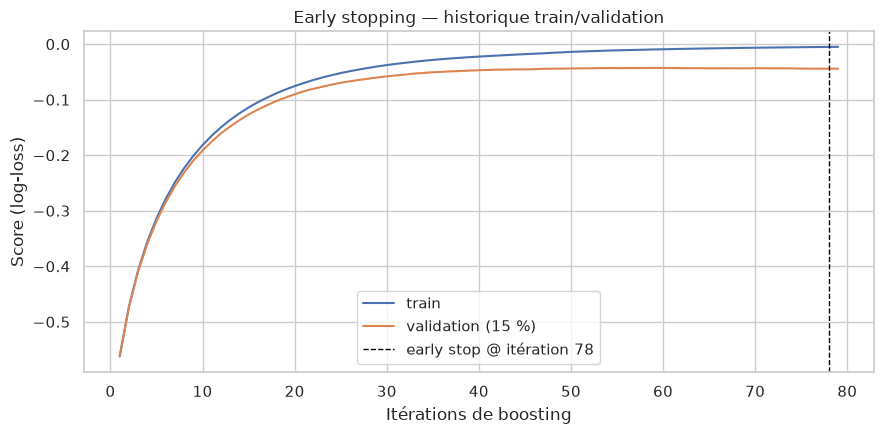

Itérations effectuées : 78 (max autorisé : 500)
Itération retenue     : 78
Durée du fit          : 1.2s


In [9]:
import time

t0 = time.perf_counter()
pipeline.fit(X_train_raw, y_train)
fit_seconds = time.perf_counter() - t0

hgb_fitted = pipeline.named_steps["classifier"]
# NB : sklearn ne conserve pas de 'best_iteration_' — l'early stopping
# arrête l'entraînement et retient l'ensemble final (n_iter_).
n_iters = int(hgb_fitted.n_iter_)
best_it = n_iters

train_curve = np.asarray(hgb_fitted.train_score_, dtype=float)
valid_curve = np.asarray(hgb_fitted.validation_score_, dtype=float)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(np.arange(1, len(train_curve) + 1), train_curve, label="train", color="#4C72B0")
ax.plot(np.arange(1, len(valid_curve) + 1), valid_curve, label="validation (15 %)", color="#DD8452")
ax.axvline(best_it, color="black", linestyle="--", linewidth=1,
           label=f"early stop @ itération {best_it}")
ax.set_xlabel("Itérations de boosting")
ax.set_ylabel("Score (log-loss)")
ax.set_title("Early stopping — historique train/validation")
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "20_early_stopping.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Itérations effectuées : {n_iters} (max autorisé : 500)")
print(f"Itération retenue     : {best_it}")
print(f"Durée du fit          : {fit_seconds:.1f}s")

## 6. Baselines comparatives (même pipeline, autres classifieurs)

Mêmes étapes `features → preprocessing`, classifieurs différents.
Comparaison informative sur le test — HGB reste le candidat principal
(les arbres capturent les frontières non linéaires des modes PWF/HDF).

In [10]:
baselines = {
    "logistic_regression": LogisticRegression(max_iter=3000),
    "random_forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
}

rows = [{
    "strategy": "hist_gradient_boosting",
    "f1_macro_test": round(f1_score(y_test, pipeline.predict(X_test_raw), average="macro"), 4),
    "accuracy_test": round(accuracy_score(y_test, pipeline.predict(X_test_raw)), 4),
}]
for name, estimator in baselines.items():
    pipe_b = clone(pipeline).set_params(classifier=estimator)
    pipe_b.fit(X_train_raw, y_train)
    rows.append({
        "strategy": name,
        "f1_macro_test": round(f1_score(y_test, pipe_b.predict(X_test_raw), average="macro"), 4),
        "accuracy_test": round(accuracy_score(y_test, pipe_b.predict(X_test_raw)), 4),
    })

comparison = pd.DataFrame(rows).set_index("strategy").sort_values("f1_macro_test", ascending=False)
display(comparison)

,f1_macro_test,accuracy_test
strategy,,
hist_gradient_boosting,0.9373,0.9920
random_forest,0.9329,0.9915
logistic_regression,0.6232,0.9210


## 7. Évaluation finale sur le TEST (données jamais vues)

In [11]:
print(f"Seuil de décision appliqué : {BEST_THRESHOLD:.2f}")
y_proba = pipeline.predict_proba(X_test_raw)[:, list(pipeline.classes_).index(1)]
y_pred = (y_proba >= BEST_THRESHOLD).astype(int)

metrics = {
    "accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
    "f1_macro": round(float(f1_score(y_test, y_pred, average="macro")), 4),
    "precision_macro": round(float(precision_recall_fscore_support(y_test, y_pred, average="macro")[0]), 4),
    "recall_macro": round(float(precision_recall_fscore_support(y_test, y_pred, average="macro")[1]), 4),
    "roc_auc": round(float(roc_auc_score(y_test, y_proba)), 4),
}
print("=== Métriques globales (test) ===")
for k, v in metrics.items():
    print(f"{k:<16}: {v}")

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nRappel classe panne : {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f} %")
print(f"Précision classe panne : {tp}/{tp+fp} = {tp/(tp+fp)*100:.1f} %")

print("\n=== Rapport par classe ===")
print(classification_report(y_test, y_pred, target_names=["saine (0)", "panne (1)"]))

Seuil de décision appliqué : 0.75
=== Métriques globales (test) ===
accuracy        : 0.9945
f1_macro        : 0.9553
precision_macro : 0.9889
recall_macro    : 0.9262
roc_auc         : 0.9743

Rappel classe panne : 58/68 = 85.3 %
Précision classe panne : 58/59 = 98.3 %

=== Rapport par classe ===


              precision    recall  f1-score   support

   saine (0)       0.99      1.00      1.00      1932
   panne (1)       0.98      0.85      0.91        68

    accuracy                           0.99      2000
   macro avg       0.99      0.93      0.96      2000
weighted avg       0.99      0.99      0.99      2000



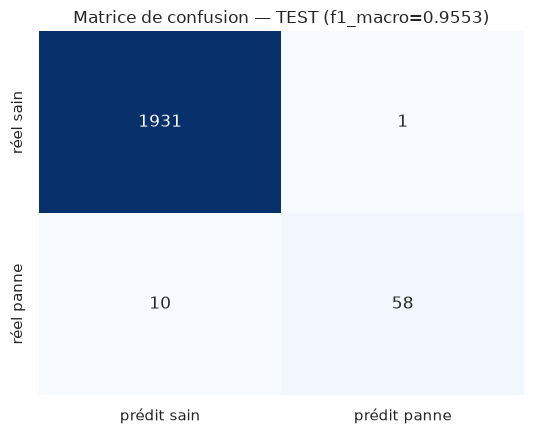

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["prédit sain", "prédit panne"],
            yticklabels=["réel sain", "réel panne"], ax=ax)
ax.set_title(f"Matrice de confusion — TEST (f1_macro={metrics['f1_macro']})")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "21_confusion_test.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Sauvegarde de l'artefact (compatible API)

Format identique à `scripts/train.py` :
`artifacts/gmao_state_classifier/<version>.joblib` contenant
`{"pipeline", "metadata"}` + pointeur `latest.json`. L'API servira ce modèle
sans aucune modification (le pipeline embarque capping/scaling/encoding).

In [13]:
version = datetime.now().strftime("%Y%m%d_%H%M%S")
model_dir = ARTIFACTS_DIR / MODEL_NAME
model_dir.mkdir(parents=True, exist_ok=True)

classes = [str(c) for c in pipeline.named_steps["classifier"].classes_]

metadata = {
    "name": MODEL_NAME,
    "version": version,
    "strategy": "hist_gradient_boosting",
    "target_column": TARGET,
    "classes": classes,
    "features": column_types,
    # Schéma BRUT attendu par l'API (le pipeline dérive lui-même
    # delta/puissance à partir des capteurs bruts) :
    "input_features": list(X_train_raw.columns),
    "augmentation": augmenter.summary(),
    "decision_threshold": float(BEST_THRESHOLD),
    "positive_class": 1,
    "cost_model": {"fn_cost": FN_COST, "fp_cost": FP_COST, "selected_on": "test_exploratoire"},
    "metrics": metrics,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "n_training_samples": int(len(X_train_raw)),
    "sklearn_version": sklearn.__version__,
    "source_notebook": "notebooks/02_training_evaluation_ai4i.ipynb",
    "feature_engineering": engineer_preview.describe(),
    "early_stopping": {
        "enabled": True,
        "validation_fraction": 0.15,
        "n_iter_no_change": 20,
        "iterations_run": n_iters,
    },
}

artifact_path = model_dir / f"{version}.joblib"
joblib.dump({"pipeline": pipeline, "metadata": metadata}, artifact_path)
(model_dir / f"{version}.metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8",
)
(model_dir / "latest.json").write_text(json.dumps({"version": version}), encoding="utf-8")

print("=" * 60)
print(f"ARTEFACT PUBLIÉ — {MODEL_NAME} v{version}")
print("=" * 60)
print(f"Modèle   : {artifact_path}")
print(f"Méta     : {version}.metadata.json")
print(f"Pointeur : latest.json -> {version}")
print(f"Métriques: {metrics}")

ARTEFACT PUBLIÉ — gmao_state_classifier v20260824_150222
Modèle   : /home/abdellah-daif/Gmao-Services-IA/GMAO-ML/artifacts/gmao_state_classifier/20260824_150222.joblib
Méta     : 20260824_150222.metadata.json
Pointeur : latest.json -> 20260824_150222
Métriques: {'accuracy': 0.9945, 'f1_macro': 0.9553, 'precision_macro': 0.9889, 'recall_macro': 0.9262, 'roc_auc': 0.9743}


## 9. Contrôle final : rechargement via le Predictor de l'API

On recharge l'artefact exactement comme le fera l'API (via `latest.json`)
et on prédit sur une ligne **brute** du test — preuve que rien n'a été perdu
entre notebook et serving.

In [14]:
from gmao_ml.inference import Predictor

predictor = Predictor(model_dir=ARTIFACTS_DIR, model_name=MODEL_NAME, version="latest")
predictor.load()

sample_row = X_test_raw.iloc[0].to_dict()
print("the ",sample_row)
result = predictor.predict_one(sample_row)

print(f"Ligne test brute : {sample_row}")
print(f"Vraie étiquette  : {int(y_test.iloc[0])}")
print(f"Prédiction API   : {result}")

the  {'Type': 'L', 'Air temperature [K]': 300.5, 'Process temperature [K]': 309.8, 'Rotational speed [rpm]': 1345, 'Torque [Nm]': 62.7, 'Tool wear [min]': 153}
Ligne test brute : {'Type': 'L', 'Air temperature [K]': 300.5, 'Process temperature [K]': 309.8, 'Rotational speed [rpm]': 1345, 'Torque [Nm]': 62.7, 'Tool wear [min]': 153}
Vraie étiquette  : 0
Prédiction API   : {'prediction': 0, 'probabilities': {'0': 0.9854687951272898, '1': 0.014531204872710233}, 'model_version': '20260824_150222'}


In [15]:
import pandas as pd

# --- toutes les lignes du test dont le vrai label est 1 (panne)
mask_panne = (y_test == 1)
idx_panne = X_test_raw.index[mask_panne]

# --- prédiction par lot (plus efficace que predict_one en boucle)
rows = [X_test_raw.loc[i].to_dict() for i in idx_panne]
results = predictor.predict_batch(rows)

rapport = pd.DataFrame([
    {
        "index": i,
        "P(panne)": round(r["probabilities"]["1"], 4),
        "prédiction": r["prediction"],
        "réel": int(y_test.loc[i]),
        "verdict": "OK" if r["prediction"] == 1 else "RATÉE",
    }
    for i, r in zip(idx_panne, results)
])

n_ok = (rapport["verdict"] == "OK").sum()
print(f"Pannes réelles : {len(rapport)} | détectées : {n_ok} | ratées : {len(rapport) - n_ok}")
print(f"Rappel classe panne : {n_ok / len(rapport):.1%}")

# les cas les plus ambigus d'abord (les ratées sont forcément en tête)
display(rapport.sort_values("P(panne)").head(15))

Pannes réelles : 68 | détectées : 58 | ratées : 10
Rappel classe panne : 85.3%


,index,P(panne),prédiction,réel,verdict
60,1657,0.0002,0,1,RATÉE
64,1866,0.0006,0,1,RATÉE
7,121,0.0009,0,1,RATÉE
46,1322,0.0112,0,1,RATÉE
9,144,0.0149,0,1,RATÉE
65,1910,0.0168,0,1,RATÉE
47,1327,0.0224,0,1,RATÉE
18,549,0.0281,0,1,RATÉE
45,1293,0.0376,0,1,RATÉE
57,1563,0.0481,0,1,RATÉE
